In [151]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass, field
from typing import List, Tuple
import math
import os

os.makedirs('result', exist_ok=True)

In [152]:
# =============================================================================
# Cell 1: TrainConfig
# =============================================================================

REGIMES = {
    0: {'alpha': 0.03, 'beta': 0.94, 'label': 'stable'},
    1: {'alpha': 0.08, 'beta': 0.89, 'label': 'alert'},
    2: {'alpha': 0.15, 'beta': 0.82, 'label': 'danger'},
}

@dataclass
class TrainConfig:
    # A-S model parameters
    gamma: float = 0.1
    A: float = 140.0
    k: float = 1.5
    q0: int = 0
    dt: float = 0.005
    n_steps: int = 200

    # Stock parameters
    S_stock_0: float = 800.0
    sigma_stock: float = 10.0    # 주가 경로 변동성 (develop 동일)
    drift: float = 10.0          # % 단위, 수동 조절

    # BSM parameters
    K: float = 800.0
    r: float = 0.03
    T_option: float = 0.082
    sigma_bsm: float = 0.2

    # Develop extensions (계승)
    n_levels: int = 3
    tick_size: float = 0.05
    buckets: List[Tuple[float, float]] = field(default_factory=lambda: [
        (0.02, 1.0), (0.05, 1.5), (0.10, 2.5), (float('inf'), 3.5)
    ])

    # GARCH(1,1)
    garch_vl: float = 4      # 장기평균 분산 (sigma=10 → sigma²=100)

    # Reward
    lambda_inv: float = 0.5      # 재고 벌점 강도

config = TrainConfig(drift=5)

In [153]:
# =============================================================================
# Cell 2: BSM 함수 + 체결 로직 (develop.ipynb에서 계승)
# =============================================================================

# --- BSM ---
def norm_cdf(x):
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))

def bsm_call_price(S, K, T, r, sigma):
    if T <= 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * norm_cdf(d1) - K * math.exp(-r * T) * norm_cdf(d2)

def bsm_delta(S, K, T, r, sigma):
    if T <= 0:
        return 1.0 if S > K else 0.0
    d1 = (math.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * math.sqrt(T))
    return norm_cdf(d1)

def generate_option_path(stock_prices, config):
    option_prices = np.array([
        bsm_call_price(S, config.K, config.T_option, config.r, config.sigma_bsm)
        for S in stock_prices
    ])
    deltas = np.array([
        bsm_delta(S, config.K, config.T_option, config.r, config.sigma_bsm)
        for S in stock_prices
    ])
    return option_prices, deltas

# --- Tick ---
def tick_floor(price, tick_size):
    return np.floor(price / tick_size) * tick_size

def tick_ceil(price, tick_size):
    return np.ceil(price / tick_size) * tick_size

# --- Fill probability (develop 계승) ---
def get_fill_multiplier(price_change_pct, config):
    abs_change = abs(price_change_pct)
    for threshold, multiplier in config.buckets:
        if abs_change < threshold:
            return multiplier
    return config.buckets[-1][1]

def compute_fill_probability(delta, stock_prev, stock_current, is_bid, config):
    if delta <= 0:
        return 1.0
    base_intensity = config.A * np.exp(-config.k * delta)
    base_prob = min(base_intensity * config.dt, 1.0)
    stock_change_pct = (stock_current - stock_prev) / stock_prev * 100
    multiplier = get_fill_multiplier(stock_change_pct, config)
    if stock_change_pct > 0:
        if not is_bid:
            return min(base_prob * multiplier, 1.0)
        else:
            return max(base_prob / multiplier, 0.0)
    elif stock_change_pct < 0:
        if is_bid:
            return min(base_prob * multiplier, 1.0)
        else:
            return max(base_prob / multiplier, 0.0)
    return base_prob

# --- Train 수식 (변경: sigma^2*(T-t) → sigma_new^2) ---
def compute_rp_train(s, net_delta, sigma_new_sq, config):
    return s - net_delta * config.gamma * sigma_new_sq

def compute_spread_train(sigma_new_sq, config):
    return config.gamma * sigma_new_sq + (2 / config.gamma) * np.log(1 + config.gamma / config.k)

def compute_quotes_train(s, net_delta, sigma_new_sq, config):
    rp = compute_rp_train(s, net_delta, sigma_new_sq, config)
    spread = compute_spread_train(sigma_new_sq, config)
    bid = tick_floor(rp - spread / 2, config.tick_size)
    ask = tick_ceil(rp + spread / 2, config.tick_size)
    return bid, ask

In [154]:
# =============================================================================
# Cell 3: GARCH 경로 생성 + MMEnvironment
# =============================================================================

class GarchPathGenerator:
    """GARCH(1,1) 기반 주가 경로 생성 (sigma 동적)"""

    def __init__(self, config: TrainConfig, regime_sequence: np.ndarray = None):
        self.config = config
        self.regime_sequence = regime_sequence  # 외부에서 주입 가능

    def generate(self) -> Tuple[np.ndarray, np.ndarray]:
        """주가 경로와 GARCH sigma^2 경로를 반환"""
        c = self.config
        n = c.n_steps

        sigma_sq = np.zeros(n + 1)
        sigma_sq[0] = c.garch_vl
        prices = np.zeros(n + 1)
        prices[0] = c.S_stock_0
        returns = np.zeros(n + 1)
        drift_abs = c.S_stock_0 * c.drift / 100

        for t in range(n):
            # regime 결정: 외부 시퀀스가 없으면 regime 0 (baseline)
            if self.regime_sequence is not None and t < len(self.regime_sequence):
                regime = int(self.regime_sequence[t])
            else:
                regime = 0
            alpha = REGIMES[regime]['alpha']
            beta = REGIMES[regime]['beta']
            omega = (1 - alpha - beta) * c.garch_vl

            Z = np.random.randn()
            # 주가 경로: sigma_stock 사용 (develop 동일)
            r_t = c.sigma_stock * np.sqrt(c.dt) * Z
            returns[t] = r_t
            prices[t + 1] = prices[t] + drift_abs * c.dt + r_t

            # GARCH(1,1) 업데이트
            sigma_sq[t + 1] = omega + alpha * r_t**2 + beta * sigma_sq[t]

        return prices, sigma_sq


class MMEnvironment:
    """MM 시뮬레이션 환경 (MDP reference의 SmartphoneModel에 대응)"""

    def __init__(self, config: TrainConfig):
        self.config = config

    def reset(self, seed=None):
        """새 episode 시작"""
        if seed is not None:
            np.random.seed(seed)

        c = self.config
        # baseline GARCH 경로 생성 (regime 0으로 초기 생성)
        gen = GarchPathGenerator(c)
        self.stock_prices, self.sigma_sq_path = gen.generate()
        self.option_prices, self.deltas = generate_option_path(self.stock_prices, c)

        self.inventory = c.q0
        self.cash = 0.0
        self.t = 0
        self.max_abs_inventory = 0
        self.prev_return = 0.0

        # step 0 호가 설정 (1-step lag)
        s0 = self.option_prices[0]
        net_delta_0 = self.inventory * self.deltas[0]
        sigma_new_sq_0 = self.sigma_sq_path[0]
        bid0, ask0 = compute_quotes_train(s0, net_delta_0, sigma_new_sq_0, c)
        self.bid_levels_prev = [bid0 - i * c.tick_size for i in range(c.n_levels)]
        self.ask_levels_prev = [ask0 + i * c.tick_size for i in range(c.n_levels)]

        return self._get_state()

    def _get_state(self):
        return {
            'net_delta': self.inventory * self.deltas[self.t],
            'sigma_sq_garch': self.sigma_sq_path[self.t],
            'inventory': self.inventory,
            'step': self.t,
            'prev_return': self.prev_return,
        }

    def step(self, regime: int) -> Tuple[dict, float, bool]:
        """1 step 진행. regime이 action."""
        c = self.config
        self.t += 1
        if self.t >= c.n_steps:
            return self._get_state(), 0.0, True

        s = self.option_prices[self.t]
        s_stock = self.stock_prices[self.t]
        s_stock_prev = self.stock_prices[self.t - 1]
        delta_t = self.deltas[self.t]

        # --- 체결 판정 (t-1 호가 vs t시점 mid) ---
        bid_fills = [False] * c.n_levels
        ask_fills = [False] * c.n_levels
        for i in range(c.n_levels):
            delta_bid = s - self.bid_levels_prev[i]
            delta_ask = self.ask_levels_prev[i] - s
            prob_bid = compute_fill_probability(delta_bid, s_stock_prev, s_stock, True, c)
            prob_ask = compute_fill_probability(delta_ask, s_stock_prev, s_stock, False, c)
            bid_fills[i] = np.random.random() < prob_bid
            ask_fills[i] = np.random.random() < prob_ask

        # sweep 보정
        for i in range(c.n_levels - 1, 0, -1):
            if bid_fills[i]:
                bid_fills[i - 1] = True
            if ask_fills[i]:
                ask_fills[i - 1] = True

        # 체결 실행
        total_bid_cost = 0.0
        total_ask_revenue = 0.0
        bid_fill_count = 0
        ask_fill_count = 0
        for i in range(c.n_levels):
            if bid_fills[i]:
                delta_bid = s - self.bid_levels_prev[i]
                fill_price = s if delta_bid <= 0 else self.bid_levels_prev[i]
                total_bid_cost += fill_price
                bid_fill_count += 1
            if ask_fills[i]:
                delta_ask = self.ask_levels_prev[i] - s
                fill_price = s if delta_ask <= 0 else self.ask_levels_prev[i]
                total_ask_revenue += fill_price
                ask_fill_count += 1

        self.inventory += bid_fill_count - ask_fill_count
        self.cash += total_ask_revenue - total_bid_cost
        self.max_abs_inventory = max(self.max_abs_inventory, abs(self.inventory))

        # --- GARCH 업데이트 (선택된 regime 반영) ---
        alpha = REGIMES[regime]['alpha']
        beta = REGIMES[regime]['beta']
        omega = (1 - alpha - beta) * c.garch_vl
        r_t = s_stock - s_stock_prev  # 절대 변화량 (GARCH 스케일 통일)
        self.prev_return = (s_stock - s_stock_prev) / s_stock_prev * 100
        self.sigma_sq_path[self.t] = omega + alpha * r_t**2 + beta * self.sigma_sq_path[self.t - 1]

        # --- 새 호가 설정 ---
        sigma_new_sq = self.sigma_sq_path[self.t]
        net_delta_after = self.inventory * delta_t
        bid_new, ask_new = compute_quotes_train(s, net_delta_after, sigma_new_sq, c)
        self.bid_levels_prev = [bid_new - i * c.tick_size for i in range(c.n_levels)]
        self.ask_levels_prev = [ask_new + i * c.tick_size for i in range(c.n_levels)]

        done = (self.t >= c.n_steps - 1)
        return self._get_state(), sigma_new_sq, done


    def step_continuous(self, alpha_t: float, beta_t: float) -> Tuple[dict, float, bool]:
        """1 step 진행. alpha, beta를 직접 받음 (sigmoid policy용)"""
        c = self.config
        self.t += 1
        if self.t >= c.n_steps:
            return self._get_state(), 0.0, True

        s = self.option_prices[self.t]
        s_stock = self.stock_prices[self.t]
        s_stock_prev = self.stock_prices[self.t - 1]
        delta_t = self.deltas[self.t]

        # 체결 판정 (t-1 호가 vs t시점 mid)
        bid_fills = [False] * c.n_levels
        ask_fills = [False] * c.n_levels
        for i in range(c.n_levels):
            delta_bid = s - self.bid_levels_prev[i]
            delta_ask = self.ask_levels_prev[i] - s
            prob_bid = compute_fill_probability(delta_bid, s_stock_prev, s_stock, True, c)
            prob_ask = compute_fill_probability(delta_ask, s_stock_prev, s_stock, False, c)
            bid_fills[i] = np.random.random() < prob_bid
            ask_fills[i] = np.random.random() < prob_ask

        for i in range(c.n_levels - 1, 0, -1):
            if bid_fills[i]:
                bid_fills[i - 1] = True
            if ask_fills[i]:
                ask_fills[i - 1] = True

        total_bid_cost = 0.0
        total_ask_revenue = 0.0
        bid_fill_count = 0
        ask_fill_count = 0
        for i in range(c.n_levels):
            if bid_fills[i]:
                delta_bid = s - self.bid_levels_prev[i]
                fill_price = s if delta_bid <= 0 else self.bid_levels_prev[i]
                total_bid_cost += fill_price
                bid_fill_count += 1
            if ask_fills[i]:
                delta_ask = self.ask_levels_prev[i] - s
                fill_price = s if delta_ask <= 0 else self.ask_levels_prev[i]
                total_ask_revenue += fill_price
                ask_fill_count += 1

        self.inventory += bid_fill_count - ask_fill_count
        self.cash += total_ask_revenue - total_bid_cost
        self.max_abs_inventory = max(self.max_abs_inventory, abs(self.inventory))

        # GARCH 업데이트 (alpha, beta 직접 사용)
        omega = (1 - alpha_t - beta_t) * c.garch_vl
        r_t = s_stock - s_stock_prev  # 절대 변화량 (GARCH 스케일 일치)
        self.prev_return = r_t  # 절대 변화량
        self.sigma_sq_path[self.t] = omega + alpha_t * r_t**2 + beta_t * self.sigma_sq_path[self.t - 1]

        sigma_new_sq = self.sigma_sq_path[self.t]
        net_delta_after = self.inventory * delta_t
        bid_new, ask_new = compute_quotes_train(s, net_delta_after, sigma_new_sq, c)
        self.bid_levels_prev = [bid_new - i * c.tick_size for i in range(c.n_levels)]
        self.ask_levels_prev = [ask_new + i * c.tick_size for i in range(c.n_levels)]

        done = (self.t >= c.n_steps - 1)
        return self._get_state(), sigma_new_sq, done

    def get_final_reward(self):
        """episode 종료 후 reward 계산"""
        c = self.config
        final_pnl = self.cash + self.inventory * self.option_prices[min(self.t, c.n_steps)]
        penalty = c.lambda_inv * self.max_abs_inventory
        return final_pnl - penalty, final_pnl, self.max_abs_inventory

In [155]:
# =============================================================================
# Cell 4: MMPolicy (sigmoid 연속) + AdaptiveRLPolicy
# =============================================================================

ALPHA_MIN = 0.03
ALPHA_MAX = 0.15
BETA_SUM = 0.97    # alpha + beta = 0.97 고정

def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1.0 / (1.0 + np.exp(-x))


class MMPolicy:
    """Sigmoid 기반 연속 정책

    score = |net_delta| * theta[0] + |prev_return%| * theta[1]
    alpha_t = ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * sigmoid((score - theta[2]) / theta[3])
    beta_t  = BETA_SUM - alpha_t

    theta[0]: w_delta (score에서 net_delta 가중치)
    theta[1]: w_return (score에서 수익률 가중치)
    theta[2]: center (sigmoid 중심점, score가 이 값일 때 alpha가 중간)
    theta[3]: width (전환 폭, 클수록 완만, 작을수록 급격)
    """

    def __init__(self, theta: np.ndarray):
        self.theta = theta

    def get_alpha_beta(self, state: dict) -> Tuple[float, float]:
        score = (abs(state['net_delta']) * self.theta[0]
                 + abs(state['prev_return']) * self.theta[1])
        sig = sigmoid((score - self.theta[2]) / max(self.theta[3], 0.1))
        alpha_t = ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * sig
        beta_t = BETA_SUM - alpha_t
        return alpha_t, beta_t

    def run_episode(self, env: MMEnvironment, seed=None):
        state = env.reset(seed=seed)
        alpha_history = []
        sigma_history = []
        done = False
        while not done:
            alpha_t, beta_t = self.get_alpha_beta(state)
            alpha_history.append(alpha_t)
            state, sigma_sq, done = env.step_continuous(alpha_t, beta_t)
            sigma_history.append(sigma_sq)
        reward, pnl, max_inv = env.get_final_reward()
        return reward, pnl, max_inv, alpha_history, sigma_history


class AdaptiveRLPolicy:
    """Gradient ascent로 theta 학습 (상대적 eps)"""

    def __init__(self, config: TrainConfig,
                 theta_init: np.ndarray = None,
                 num_mc: int = 50,
                 max_iters: int = 100,
                 c_lr: float = 0.005,
                 eps_frac: float = 0.05):
        self.config = config
        self.theta = theta_init if theta_init is not None else np.array([1.0, 1.0, 5.0, 2.0])
        self.num_mc = num_mc
        self.max_iters = max_iters
        self.c_lr = c_lr
        self.eps_frac = eps_frac
        self.theta_history = []
        self.J_history = []
        self.best_theta = None
        self.best_J = -float('inf')

    def _evaluate_J(self, theta, seed_base):
        policy = MMPolicy(theta)
        rewards = []
        for i in range(self.num_mc):
            env = MMEnvironment(self.config)
            r, _, _, _, _ = policy.run_episode(env, seed=seed_base + i)
            rewards.append(r)
        return np.mean(rewards)

    def _clip_theta(self, theta):
        theta = theta.copy()
        theta[0] = np.clip(theta[0], 0.1, 5.0)     # w_delta
        theta[1] = np.clip(theta[1], 0.1, 20.0)     # w_return
        theta[2] = np.clip(theta[2], 0.5, 20.0)     # center
        theta[3] = np.clip(theta[3], 0.1, 10.0)     # width
        return theta

    def _estimate_gradient(self, theta, iteration):
        seed_base = 10000 + iteration * self.num_mc * 10
        J_current = self._evaluate_J(theta, seed_base)
        grad = np.zeros_like(theta)
        for i in range(len(theta)):
            eps_i = self.eps_frac * max(abs(theta[i]), 0.5)
            theta_plus = theta.copy()
            theta_plus[i] += eps_i
            theta_plus = self._clip_theta(theta_plus)
            J_plus = self._evaluate_J(theta_plus, seed_base)
            grad[i] = (J_plus - J_current) / eps_i
        return grad, J_current

    def learn(self, verbose=True):
        theta = self.theta.copy()
        self.theta_history = [theta.copy()]

        if verbose:
            print(f"{'Iter':>4} | {'theta':>40} | {'Reward':>10} | {'lr':>8}")
            print('-' * 75)

        for k in range(1, self.max_iters + 1):
            lr_k = self.c_lr / k
            grad, J_val = self._estimate_gradient(theta, k)
            self.J_history.append(J_val)

            if J_val > self.best_J:
                self.best_J = J_val
                self.best_theta = theta.copy()

            if verbose:
                t_str = f'({theta[0]:.3f}, {theta[1]:.2f}, {theta[2]:.3f}, {theta[3]:.3f})'
                print(f'{k:4d} | {t_str:>40} | {J_val:10.2f} | {lr_k:.4f}')

            for i in range(len(theta)):
                scale_i = max(abs(theta[i]), 0.5)
                theta[i] += lr_k * grad[i] * scale_i
            theta = self._clip_theta(theta)
            self.theta_history.append(theta.copy())

        if verbose:
            print(f'\nBest theta: {self.best_theta}')
            print(f'Best Reward: {self.best_J:.2f}')

        return self.best_theta, self.best_J


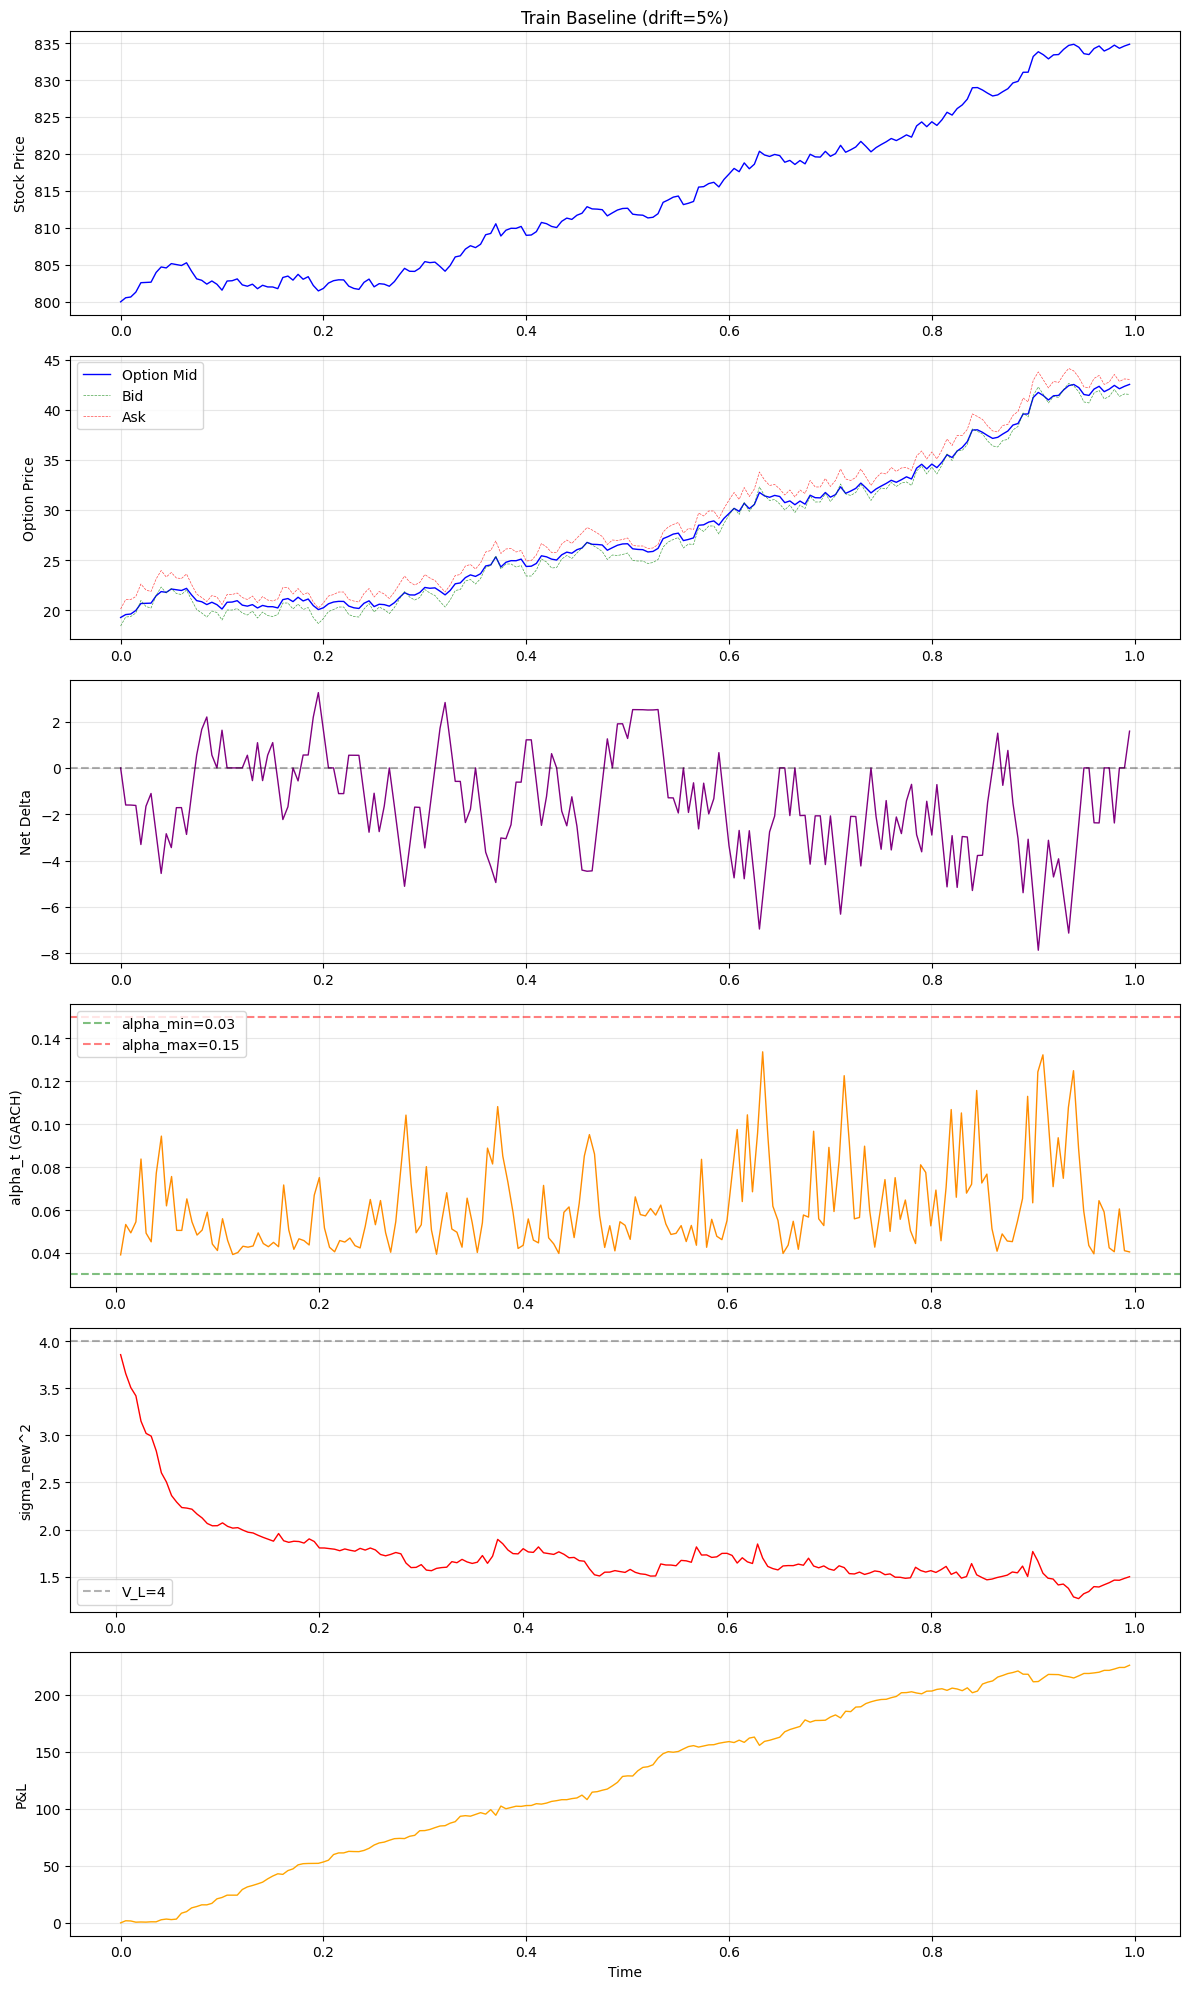

Final P&L: 225.96, Reward: 220.96
Max |inventory|: 10, Final inventory: 2
Alpha range: 0.0391 ~ 0.1337


In [156]:
# =============================================================================
# Cell 5: 단일 시뮬레이션 시각화 (baseline)
# =============================================================================

env2 = MMEnvironment(config)
baseline_policy = MMPolicy(np.array([1.0, 1.0, 5.0, 2.0]))
state = env2.reset(seed=42)

inv_rec, nd_rec, pnl_rec = [0], [0.0], [0.0]
bid_rec, ask_rec = [env2.bid_levels_prev[0]], [env2.ask_levels_prev[0]]
sigma_rec = [config.garch_vl]
alpha_rec = []

done = False
while not done:
    alpha_t, beta_t = baseline_policy.get_alpha_beta(state)
    alpha_rec.append(alpha_t)
    state, sigma_sq, done = env2.step_continuous(alpha_t, beta_t)
    inv_rec.append(env2.inventory)
    nd_rec.append(state['net_delta'])
    pnl_rec.append(env2.cash + env2.inventory * env2.option_prices[env2.t])
    bid_rec.append(env2.bid_levels_prev[0])
    ask_rec.append(env2.ask_levels_prev[0])
    sigma_rec.append(sigma_sq if sigma_sq else sigma_rec[-1])

reward_b, pnl_b, max_inv_b = env2.get_final_reward()
n = len(alpha_rec)
times_full = np.arange(n + 1) * config.dt
times_step = np.arange(1, n + 1) * config.dt

fig, axes = plt.subplots(6, 1, figsize=(12, 20))

axes[0].plot(times_full, env2.stock_prices[:n+1], 'b-', linewidth=1)
axes[0].set_ylabel('Stock Price')
axes[0].set_title(f'Train Baseline (drift={config.drift}%)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(times_full, env2.option_prices[:n+1], 'b-', label='Option Mid', linewidth=1)
axes[1].plot(times_full, bid_rec[:n+1], 'g--', label='Bid', alpha=0.7, linewidth=0.5)
axes[1].plot(times_full, ask_rec[:n+1], 'r--', label='Ask', alpha=0.7, linewidth=0.5)
axes[1].set_ylabel('Option Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(times_full, nd_rec, 'purple', linewidth=1)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[2].set_ylabel('Net Delta')
axes[2].grid(True, alpha=0.3)

axes[3].plot(times_step, alpha_rec, 'darkorange', linewidth=1)
axes[3].axhline(y=ALPHA_MIN, color='green', linestyle='--', alpha=0.5, label=f'alpha_min={ALPHA_MIN}')
axes[3].axhline(y=ALPHA_MAX, color='red', linestyle='--', alpha=0.5, label=f'alpha_max={ALPHA_MAX}')
axes[3].set_ylabel('alpha_t (GARCH)')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

axes[4].plot(times_step, sigma_rec[1:n+1], 'red', linewidth=1)
axes[4].axhline(y=config.garch_vl, color='black', linestyle='--', alpha=0.3, label=f'V_L={config.garch_vl}')
axes[4].set_ylabel('sigma_new^2')
axes[4].legend()
axes[4].grid(True, alpha=0.3)

axes[5].plot(times_full, pnl_rec, 'orange', linewidth=1)
axes[5].set_xlabel('Time')
axes[5].set_ylabel('P&L')
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('result/train_single_simulation.png', dpi=150)
plt.show()

print(f'Final P&L: {pnl_b:.2f}, Reward: {reward_b:.2f}')
print(f'Max |inventory|: {max_inv_b}, Final inventory: {env2.inventory}')
print(f'Alpha range: {min(alpha_rec):.4f} ~ {max(alpha_rec):.4f}')


In [157]:
# =============================================================================
# Cell 6: RL 학습 실행
# =============================================================================

rl = AdaptiveRLPolicy(
    config,
    theta_init=np.array([1.0, 1.0, 5.0, 2.0]),  # [w_delta, w_return, center, width]
    num_mc=50,
    max_iters=100,
    c_lr=0.005,
    eps_frac=0.05,
)

print(f'=== RL Training (drift={config.drift}%) ===')
print(f'Sigmoid policy: alpha = {ALPHA_MIN} + {ALPHA_MAX-ALPHA_MIN:.2f} * sigmoid((score - center) / width)')
print()
best_theta, best_J = rl.learn(verbose=True)

=== RL Training (drift=5%) ===
Sigmoid policy: alpha = 0.03 + 0.12 * sigmoid((score - center) / width)

Iter |                                    theta |     Reward |       lr
---------------------------------------------------------------------------
   1 |              (1.000, 1.00, 5.000, 2.000) |     146.40 | 0.0050
   2 |              (0.789, 0.93, 5.145, 1.925) |     162.13 | 0.0025
   3 |              (0.734, 0.90, 5.244, 1.887) |     169.21 | 0.0017
   4 |              (0.712, 0.89, 5.298, 1.863) |     168.32 | 0.0013
   5 |              (0.698, 0.89, 5.317, 1.845) |     163.37 | 0.0010
   6 |              (0.684, 0.89, 5.383, 1.834) |     157.70 | 0.0008
   7 |              (0.680, 0.89, 5.397, 1.820) |     175.60 | 0.0007
   8 |              (0.674, 0.89, 5.407, 1.811) |     169.93 | 0.0006
   9 |              (0.665, 0.89, 5.406, 1.798) |     169.35 | 0.0006
  10 |              (0.656, 0.88, 5.428, 1.792) |     170.14 | 0.0005
  11 |              (0.644, 0.88, 5.439, 1.787) 

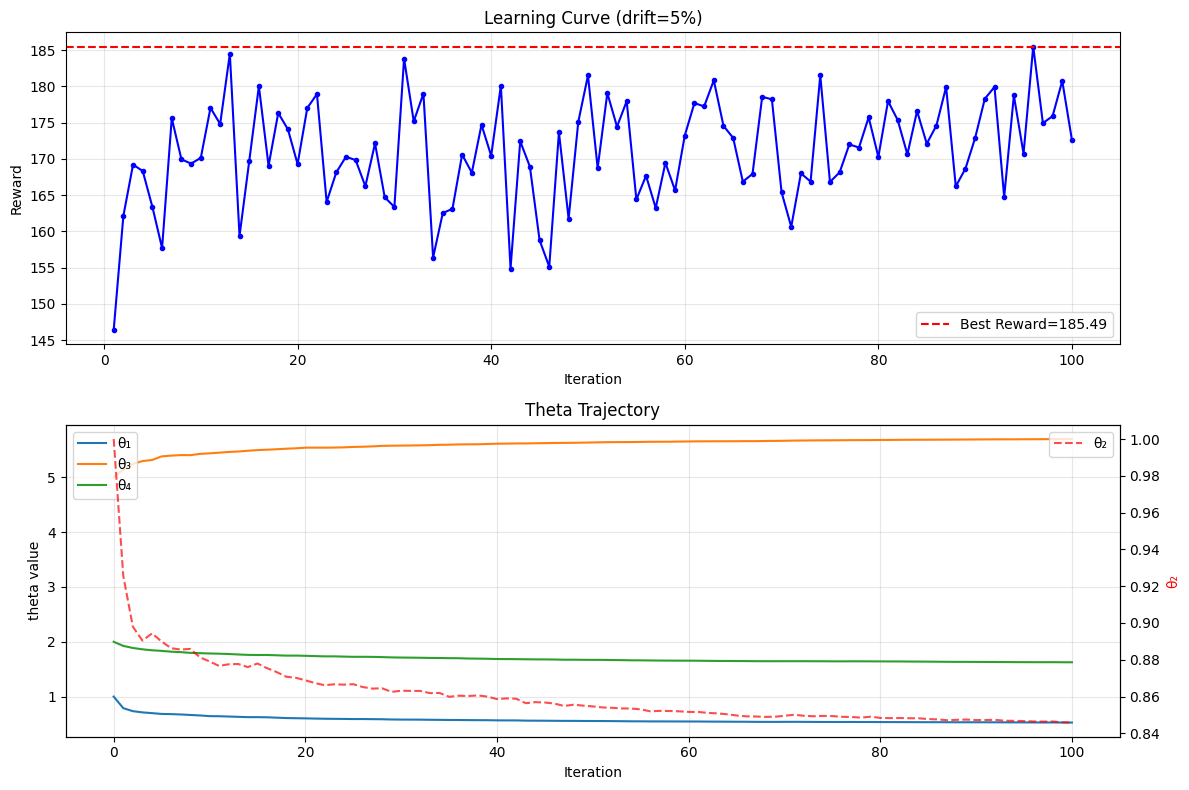

In [158]:
# =============================================================================
# Cell 7: 학습 수렴 시각화
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Reward 수렴
axes[0].plot(range(1, len(rl.J_history) + 1), rl.J_history, 'b-o', markersize=3)
axes[0].axhline(y=rl.best_J, color='red', linestyle='--', label=f'Best Reward={rl.best_J:.2f}')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Reward')
axes[0].set_title(f'Learning Curve (drift={config.drift}%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# theta 경로
theta_arr = np.array(rl.theta_history)
labels = ['θ₁', 'θ₂', 'θ₃', 'θ₄']
for i in range(4):
    vals = theta_arr[:, i]
    if i == 1:  # w_return 스케일이 크므로 오른쪽 축
        ax2 = axes[1].twinx()
        ax2.plot(range(len(vals)), vals, 'r--', label=labels[i], alpha=0.7)
        ax2.set_ylabel('θ₂', color='red')
        ax2.legend(loc='upper right')
    else:
        axes[1].plot(range(len(vals)), vals, label=labels[i])

axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('theta value')
axes[1].set_title('Theta Trajectory')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('result/train_learning_curve.png', dpi=150)
plt.show()

In [159]:
# =============================================================================
# Cell 8: 상수 baseline vs 학습된 정책 비교
# =============================================================================

n_eval = 200

# 상수 baseline: center를 매우 크게 → sigmoid ≈ 0 → alpha ≈ 0.03 항상
constant_policy = MMPolicy(np.array([1.0, 1.0, 999.0, 1.0]))
learned_policy = MMPolicy(rl.best_theta)

print(f'Evaluating {n_eval} episodes each...\n')
const_results = {'reward': [], 'pnl': [], 'max_inv': []}
learn_results = {'reward': [], 'pnl': [], 'max_inv': []}

for i in range(n_eval):
    env_c = MMEnvironment(config)
    r, p, m, _, _ = constant_policy.run_episode(env_c, seed=i)
    const_results['reward'].append(r)
    const_results['pnl'].append(p)
    const_results['max_inv'].append(m)

    env_l = MMEnvironment(config)
    r, p, m, _, _ = learned_policy.run_episode(env_l, seed=i)
    learn_results['reward'].append(r)
    learn_results['pnl'].append(p)
    learn_results['max_inv'].append(m)

print(f"{'':12} {'Reward':>10} {'P&L':>10} {'P&L Std':>10} {'Max|Inv|':>10}")
print('-' * 55)
for name, res in [('Constant', const_results), ('Learned', learn_results)]:
    print(f"{name:12} {np.mean(res['reward']):10.2f} {np.mean(res['pnl']):10.2f} "
          f"{np.std(res['pnl']):10.2f} {np.mean(res['max_inv']):10.1f}")

print(f'\nLearned theta: {rl.best_theta}')


Evaluating 200 episodes each...

                 Reward        P&L    P&L Std   Max|Inv|
-------------------------------------------------------
Constant         175.91     180.94      38.51       10.1
Learned          169.20     174.59      43.77       10.8

Learned theta: [0.5289831  0.84663224 5.69586844 1.62852894]


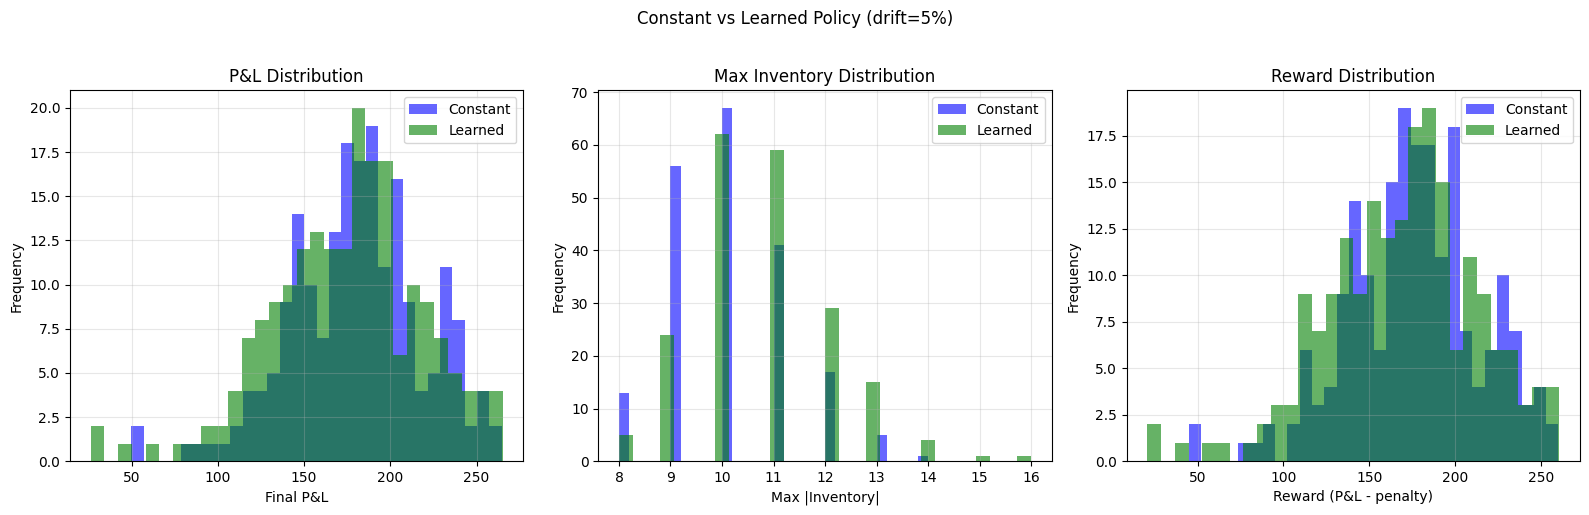

In [160]:
# =============================================================================
# Cell 9: 비교 분포 시각화
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(const_results['pnl'], bins=30, alpha=0.6, label='Constant', color='blue')
axes[0].hist(learn_results['pnl'], bins=30, alpha=0.6, label='Learned', color='green')
axes[0].set_xlabel('Final P&L')
axes[0].set_ylabel('Frequency')
axes[0].set_title('P&L Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(const_results['max_inv'], bins=30, alpha=0.6, label='Constant', color='blue')
axes[1].hist(learn_results['max_inv'], bins=30, alpha=0.6, label='Learned', color='green')
axes[1].set_xlabel('Max |Inventory|')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Max Inventory Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(const_results['reward'], bins=30, alpha=0.6, label='Constant', color='blue')
axes[2].hist(learn_results['reward'], bins=30, alpha=0.6, label='Learned', color='green')
axes[2].set_xlabel('Reward (P&L - penalty)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Reward Distribution')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Constant vs Learned Policy (drift={config.drift}%)', y=1.02)
plt.tight_layout()
plt.savefig('result/train_comparison.png', dpi=150)
plt.show()

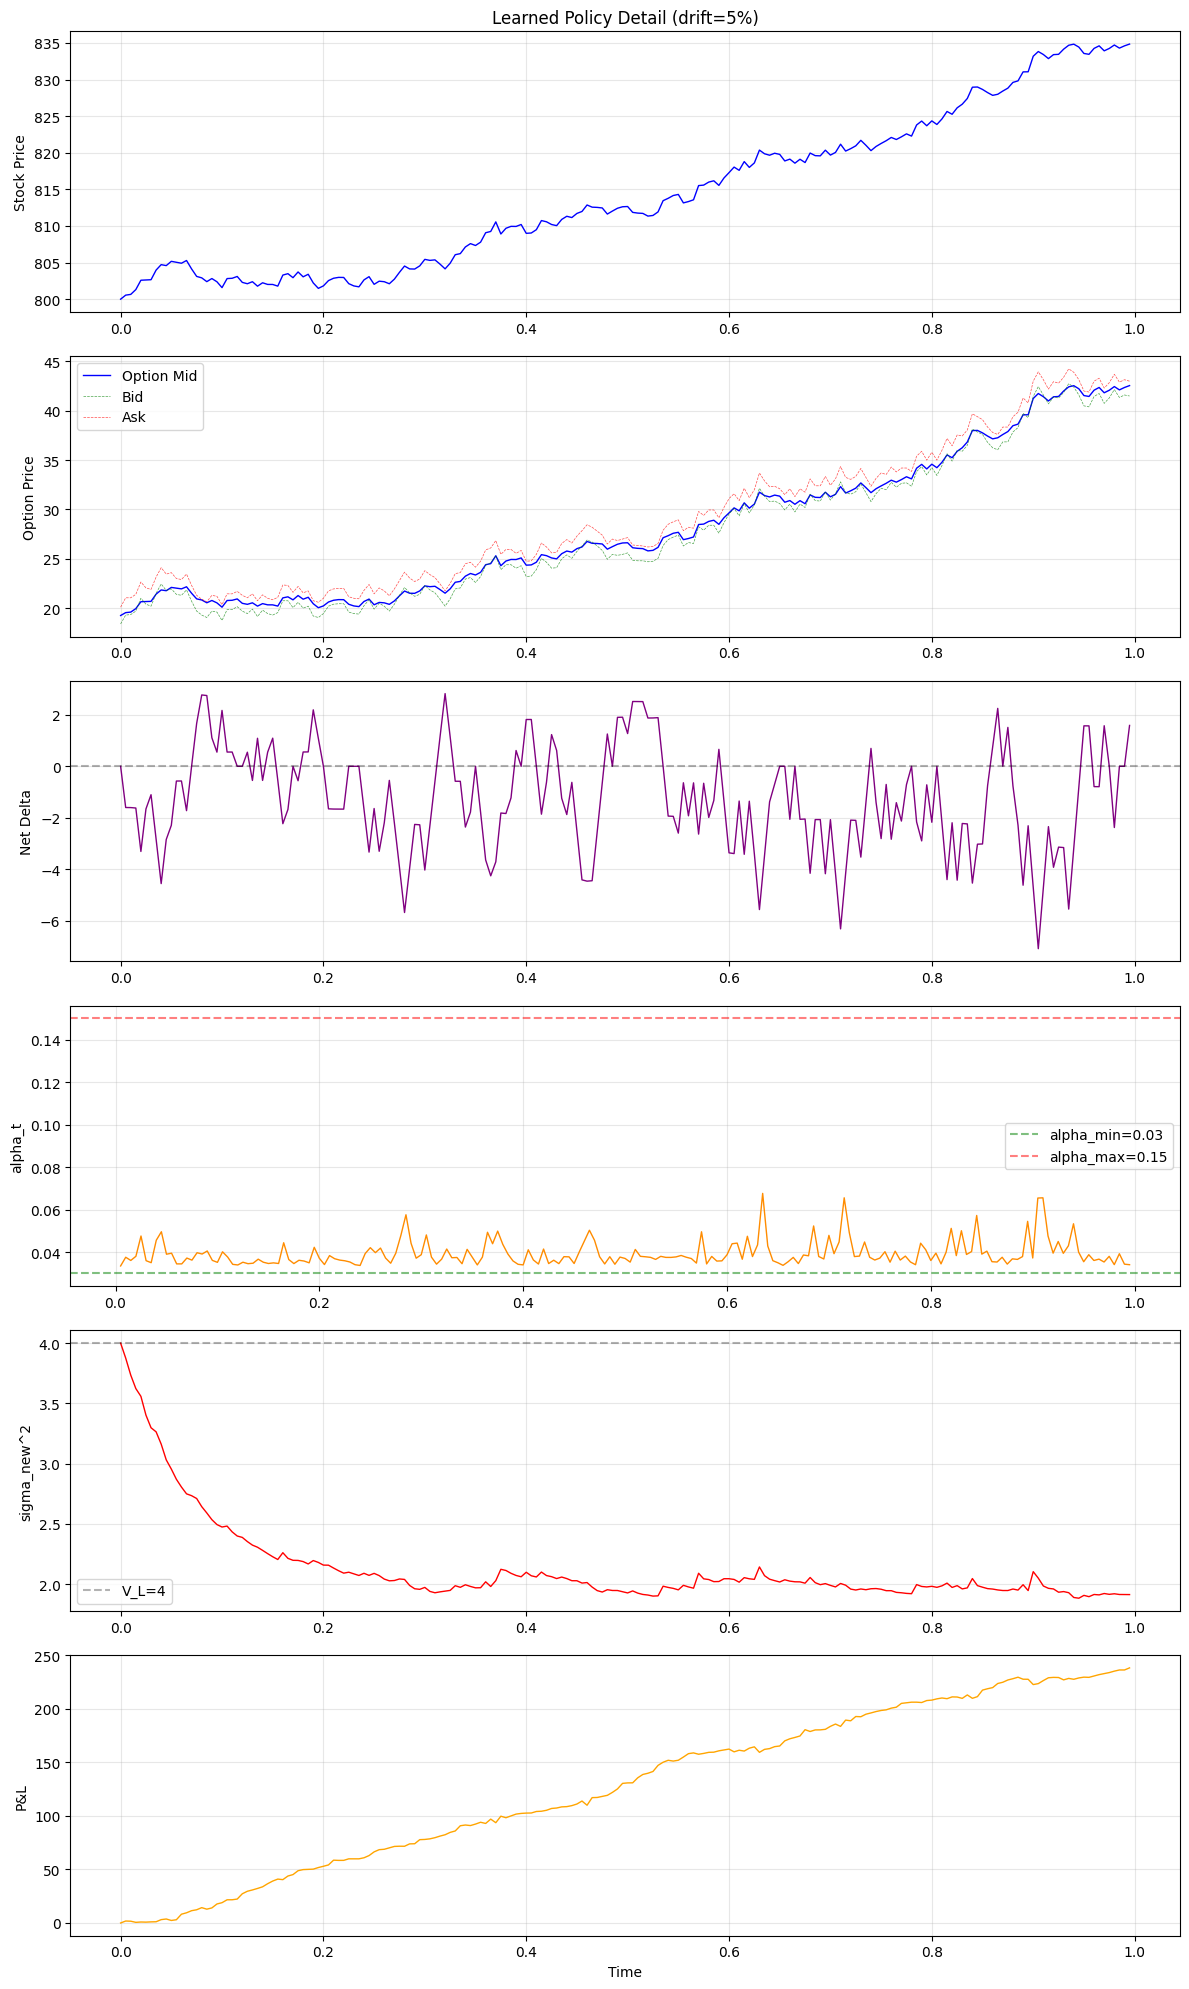

Final P&L: 238.17, Reward: 233.17, Max|Inv|: 10
Alpha range: 0.0335 ~ 0.0677
Learned theta: [0.5289831  0.84663224 5.69586844 1.62852894]


In [161]:
# =============================================================================
# Cell 10: 학습된 정책의 단일 시뮬레이션 상세 시각화
# =============================================================================

env_detail = MMEnvironment(config)
state = env_detail.reset(seed=42)

inv_rec = [0]
nd_rec = [0.0]
pnl_rec = [0.0]
bid_rec = [env_detail.bid_levels_prev[0]]
ask_rec = [env_detail.ask_levels_prev[0]]
sigma_rec = [config.garch_vl]
alpha_rec = []

done = False
while not done:
    alpha_t, beta_t = learned_policy.get_alpha_beta(state)
    alpha_rec.append(alpha_t)
    state, sigma_sq, done = env_detail.step_continuous(alpha_t, beta_t)
    inv_rec.append(env_detail.inventory)
    nd_rec.append(state['net_delta'])
    pnl_rec.append(env_detail.cash + env_detail.inventory * env_detail.option_prices[env_detail.t])
    bid_rec.append(env_detail.bid_levels_prev[0])
    ask_rec.append(env_detail.ask_levels_prev[0])
    sigma_rec.append(sigma_sq if sigma_sq else sigma_rec[-1])

reward_detail, pnl_detail, max_inv_detail = env_detail.get_final_reward()
n = len(alpha_rec)
times_full = np.arange(n + 1) * config.dt
times_step = np.arange(1, n + 1) * config.dt

fig, axes = plt.subplots(6, 1, figsize=(12, 20))

axes[0].plot(times_full, env_detail.stock_prices[:n+1], 'b-', linewidth=1)
axes[0].set_ylabel('Stock Price')
axes[0].set_title(f'Learned Policy Detail (drift={config.drift}%)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(times_full, env_detail.option_prices[:n+1], 'b-', label='Option Mid', linewidth=1)
axes[1].plot(times_full, bid_rec[:n+1], 'g--', label='Bid', alpha=0.7, linewidth=0.5)
axes[1].plot(times_full, ask_rec[:n+1], 'r--', label='Ask', alpha=0.7, linewidth=0.5)
axes[1].set_ylabel('Option Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(times_full, nd_rec, 'purple', linewidth=1)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[2].set_ylabel('Net Delta')
axes[2].grid(True, alpha=0.3)

axes[3].plot(times_step, alpha_rec, 'darkorange', linewidth=1)
axes[3].axhline(y=ALPHA_MIN, color='green', linestyle='--', alpha=0.5, label=f'alpha_min={ALPHA_MIN}')
axes[3].axhline(y=ALPHA_MAX, color='red', linestyle='--', alpha=0.5, label=f'alpha_max={ALPHA_MAX}')
axes[3].set_ylabel('alpha_t')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

axes[4].plot(times_full, sigma_rec[:n+1], 'red', linewidth=1)
axes[4].axhline(y=config.garch_vl, color='black', linestyle='--', alpha=0.3, label=f'V_L={config.garch_vl}')
axes[4].set_ylabel('sigma_new^2')
axes[4].legend()
axes[4].grid(True, alpha=0.3)

axes[5].plot(times_full, pnl_rec, 'orange', linewidth=1)
axes[5].set_xlabel('Time')
axes[5].set_ylabel('P&L')
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('result/train_learned_detail.png', dpi=150)
plt.show()

print(f'Final P&L: {pnl_detail:.2f}, Reward: {reward_detail:.2f}, Max|Inv|: {max_inv_detail}')
print(f'Alpha range: {min(alpha_rec):.4f} ~ {max(alpha_rec):.4f}')
print(f'Learned theta: {rl.best_theta}')
